# Exercício:

## 01 – Importe o .csv utilizado no exercício 1 da aula 13 e instancie um objeto da classe DataFrame. Busque no GenBank do NCBI, a sequência aminoacídica referente à cada gene, baixe o arquivo FASTA, e importe para o Python. Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

https://1drv.ms/v/c/808ebfd9a0d86213/IQCLY6g2vuPjQr-7RxF_QZK0AWue-PxKWmQ8QlMEtwIh2WA?e=qBwOpD

In [6]:
import pandas as pd
import numpy as np
from Bio import Entrez
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df_genes = pd.read_csv("genes.csv", index_col="Unnamed: 0")
df_genes.head()

,Tamanho,Início,Contagem de A,Contém hu?
BCRA1,5,BC,1,False
TP53,4,TP,0,False
HLA-A,5,HL,2,False
SOD2,4,SO,0,False
APOE,4,AP,1,False


In [8]:
df_genes['id_entrez'] = [
    "NM_007294.4",
    "NM_000546.6",
    "NM_002116.8",
    "NM_000636.4",
    "NM_000041.4",
]

df_genes['id_protein'] = [
    'NP_009225.1',
    "NP_000537.3",
    "NP_002107.3",
    "NP_000627.2",
    "NP_001289617.1",
]
df_genes

,Tamanho,Início,Contagem de A,Contém hu?,id_entrez,id_protein
BCRA1,5,BC,1,False,NM_007294.4,NP_009225.1
TP53,4,TP,0,False,NM_000546.6,NP_000537.3
HLA-A,5,HL,2,False,NM_002116.8,NP_002107.3
SOD2,4,SO,0,False,NM_000636.4,NP_000627.2
APOE,4,AP,1,False,NM_000041.4,NP_001289617.1


In [9]:
def salvar_fasta_gene(id_protein: str, nome_gene: str) -> None:
    '''
        Salva a sequência de um gene em formato FASTA.
            Args:
                id_protein (str): ID do gene no GenBank.
                nome_gene (str): Nome do gene para salvar o arquivo.
            Returns:
                None
    '''
    # Necessário informar seu email
    Entrez.email = "camillamaia36@gmail.com"

    # Busca a sequência (ex: um ID do GenBank)
    handle = Entrez.efetch(db="protein", id=id_protein, rettype="fasta", retmode="text")
    record = handle.read()
    handle.close()

    # Salva o arquivo
    with open(f"../{nome_gene}.fasta", "w") as f:
        fasta = f.write(record)
    
    return None

In [10]:
for index in df_genes.index:
    id_gene = df_genes.loc[index, "id_protein"]
    nome_gene = index 
    salvar_fasta_gene(nome_gene=nome_gene, id_protein=id_gene)
    time.sleep(10)  # Para evitar sobrecarga no servidor do NCBI
    print(nome_gene, id_gene)

BCRA1 NP_009225.1
TP53 NP_000537.3
HLA-A NP_002107.3
SOD2 NP_000627.2
APOE NP_001289617.1


In [11]:
descr_gene = {}
for gene in df_genes.index:
    caminho = f"../{gene}.fasta"
    with open(caminho, 'r') as file:
        data = file.read()
        data = data.split('\n')
        cod = data[0].split(" ")[0]
        seq = ''.join(data[1:-2])
        descr_gene[gene] = {"gene": gene, "cod": cod, "seq": seq}
descr_gene_df = pd.DataFrame.from_dict(descr_gene, orient='index')
descr_gene_df.head()

,gene,cod,seq
BCRA1,BCRA1,>NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...
TP53,TP53,>NP_000537.3,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...
HLA-A,HLA-A,>NP_002107.3,MAVMAPRTLLLLLSGALALTQTWAGSHSMRYFFTSVSRPGRGEPRF...
SOD2,SOD2,>NP_000627.2,MLSRAVCGTSRQLAPVLGYLGSRQKHSLPDLPYDYGALEPHINAQI...
APOE,APOE,>NP_001289617.1,MSSGASRKSWDPGNPWPPDWPITGRKMKVLWAALLVTFLAGCQAKV...


## 02 – Importe o .csv as informações dos aminoácidos e instancie um objeto da classe DataFrame. Obtenha a frequência absoluta de cada um dos aminoácidos para cada um dos genes. Instancie um objeto da classe DataFrame com as informações.

In [12]:
from collections import Counter

freq_aminoacidos = {}

for index, row in descr_gene_df.iterrows():
    gene = row["gene"]
    sequencia = row["seq"]
    
    freq_aminoacidos[gene] = Counter(sequencia)

freq_aminoacidos_df = pd.DataFrame(freq_aminoacidos).fillna(0).astype(int)

freq_aminoacidos_df

,BCRA1,TP53,HLA-A,SOD2,APOE
M,30,12,8,3,9
D,85,20,24,8,13
L,156,32,29,24,41
S,224,38,24,10,18
A,84,24,36,19,40
R,76,26,28,7,36
V,101,18,22,11,24
E,198,30,23,12,40
Q,97,15,22,12,32
N,121,14,4,14,2


In [13]:
mapa_aa = {
    'M': 'Metionina',
    'A': 'Alanina',
    'R': 'Arginina',
    'N': 'Asparagina',
    'D': 'Aspartato',
    'C': 'Cisteína',
    'Q': 'Glutamina',
    'E': 'Glutamato',
    'G': 'Glicina',
    "H": "Histidina",
    "I": "Isoleucina",
    "L": "Leucina",
    "K": "Lisina",
    "F": "Fenilalanina",
    "P": "Prolina",
    "S": "Serina",
    "T": "Treonina",
    "W": "Triptofano",
    "Y": "Tirosina",
    "V": "Valina",
}

freq_aminoacidos_df.rename(index=mapa_aa, inplace=True)
freq_aminoacidos_df


,BCRA1,TP53,HLA-A,SOD2,APOE
Metionina,30,12,8,3,9
Aspartato,85,20,24,8,13
Leucina,156,32,29,24,41
Serina,224,38,24,10,18
Alanina,84,24,36,19,40
Arginina,76,26,28,7,36
Valina,101,18,22,11,24
Glutamato,198,30,23,12,40
Glutamina,97,15,22,12,32
Asparagina,121,14,4,14,2


In [28]:
freq_aminoacidos_df.to_csv('genes_aa.csv')

## 03 – Qual é o número de Valinas presentes em cada um dos genes? Qual o gene tem o maior número?

In [14]:
valinas = freq_aminoacidos_df.loc['Valina']
valinas

BCRA1    101
TP53      18
HLA-A     22
SOD2      11
APOE      24
Name: Valina, dtype: int64

In [15]:
valinas.idxmax()

'BCRA1'

## 04 – Qual a média, a mediana e a moda da frequência absoluta de Serina presente nos genes?

In [16]:
serinas = freq_aminoacidos_df.loc['Serina']

media = serinas.mean()
mediana = serinas.median()
moda = serinas.mode()[0]

print('A média de serinas é:', media,)
print(f'a mediana é', mediana)
print(f'e a moda é:', moda)

A média de serinas é: 62.8
a mediana é 24.0
e a moda é: 10


## 05 – Gere um histograma, contendo a média e a mediana, com o número de Serinas por gene.

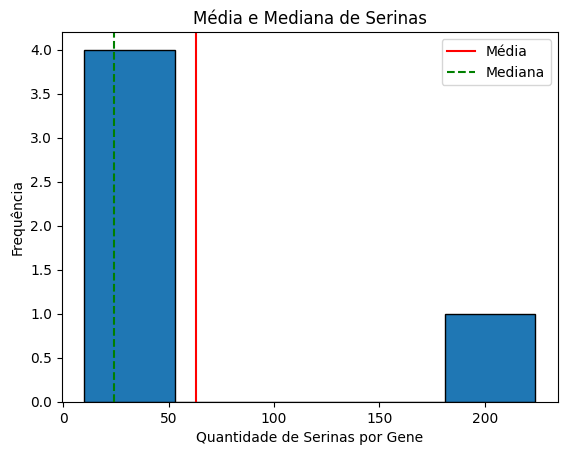

In [17]:
plt.hist(serinas, bins=5, edgecolor="black")

plt.axvline(media, color="red", linestyle="solid", label="Média")
plt.axvline(mediana, color="green", linestyle="dashed", label="Mediana")

plt.title('Média e Mediana de Serinas')
plt.xlabel('Quantidade de Serinas por Gene')
plt.ylabel('Frequência')
plt.legend()

plt.show()

## 06 – Defina uma função que receba o nome de um aa qualquer e retorne o mesmo resultado do exercício anterior.

In [18]:
def histograma_aminoacido(aminoacido):

    dados = freq_aminoacidos_df.loc[aminoacido]

    plt.hist(dados, bins=5, edgecolor="black")

    plt.axvline(dados.mean(), color="red", linestyle="dashed", label="Média")
    plt.axvline(dados.median(), color="blue", linestyle="dashed", label="Mediana")

    plt.title(f"Distribuição de {aminoacido} por gene")
    plt.xlabel("Frequência")
    plt.ylabel("Genes")
    plt.legend()

    plt.show()

## 07 – Retorne os gráficos dos aa Glutamina, Glicina, Lisina e Valina. Qual possuí menor diferença entre média e mediana?

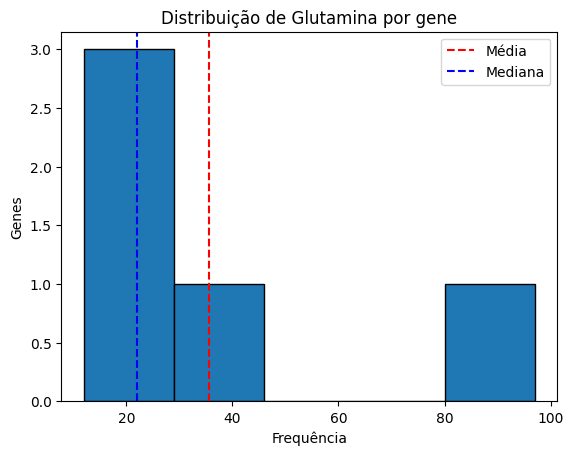

In [19]:
histograma_aminoacido('Glutamina')

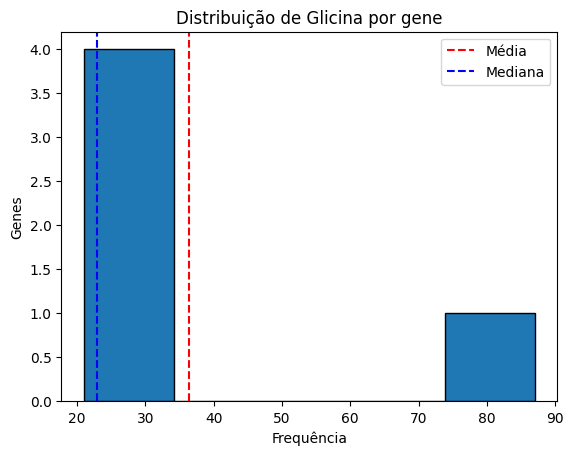

In [20]:
histograma_aminoacido('Glicina')

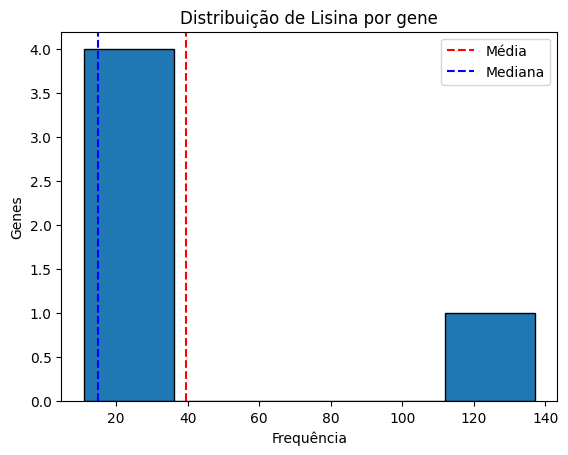

In [21]:
histograma_aminoacido('Lisina')

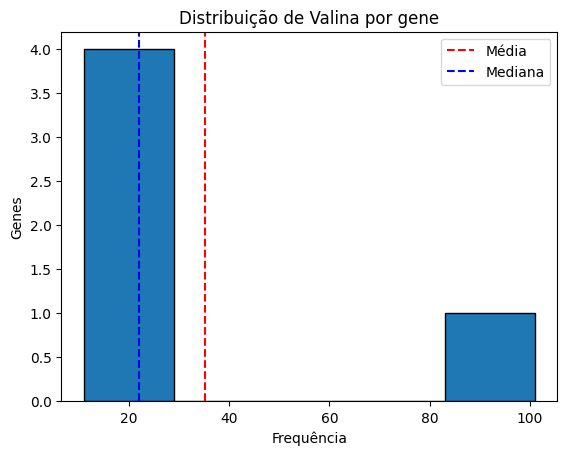

In [22]:
histograma_aminoacido('Valina')

## 08 – Dentre os três primeiros genes, qual é a média e a mediana de Cisteína?

In [23]:
cisteinas = freq_aminoacidos_df.loc["Cisteína"].iloc[:3]

media_cs = cisteinas.mean()
mediana_cs = cisteinas.median()

media_cs, mediana_cs

(np.float64(19.666666666666668), np.float64(10.0))

## 09 – Analisando o valor médio de aa em cada um dos genes, qual seria o maior gene (maior número médio de aa)?

In [24]:
media_por_gene = freq_aminoacidos_df.mean()
media_por_gene

BCRA1    93.15
TP53     19.65
HLA-A    18.25
SOD2     11.10
APOE     17.15
dtype: float64

In [25]:
media_por_gene.idxmax()

'BCRA1'

## 10 – Olhando o valor médio de aa em cada um dos genes, qual seria o menor gene (menor número médio de aa)?

In [26]:
media_por_gene.idxmin()

'SOD2'